# Determinação da idade a partir de fotografias

A rede de supermercados Boa Semente quer usar visão computacional para cumprir a lei de
venda de bebidas alcoólicas. As lojas têm câmeras no caixa que disparam quando alguém
compra álcool, e a ideia é estimar a idade da pessoa a partir dessa foto.

O objetivo deste projeto é construir e avaliar um modelo de regressão que preveja a idade
de uma pessoa a partir de sua fotografia. A métrica de avaliação é o EAM (erro absoluto
médio), e o valor no conjunto de teste não pode passar de 8 anos.

## Inicialização

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

## Carregar os dados

O conjunto de dados está armazenado na pasta `/datasets/faces/`, lá você encontra 
- A pasta `final_files` com 7,6k fotos
- O arquivo `labels.csv` com rótulos, com duas colunas: `file_name` e `real_age`

Dado que o número de arquivos de imagem é bastante alto, é aconselhável evitar a leitura de todos de uma vez, o que consumiria muito recursos computacionais. Recomendamos que você crie um gerador com o ImageDataGenerator. Este método foi explicado no Capítulo 3, Lição 7 deste curso.

O arquivo de etiqueta pode ser carregado como um arquivo CSV usual.

In [2]:
caminho = '/datasets/faces/'

labels = pd.read_csv(caminho + 'labels.csv')

labels.info()
display(labels.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


## EDA

Começo pelo tamanho do conjunto e pela consistência básica: valores ausentes, nomes de
arquivo repetidos e faixa de idades registrada.

In [3]:
print('Número de fotos:', labels.shape[0])
print('Valores ausentes:', labels.isna().sum().sum())
print('Nomes de arquivo duplicados:', labels['file_name'].duplicated().sum())
print()
display(labels['real_age'].describe())

Número de fotos: 7591
Valores ausentes: 0
Nomes de arquivo duplicados: 0



count    7591.000000
mean       31.201159
std        17.145060
min         1.000000
25%        20.000000
50%        29.000000
75%        41.000000
max       100.000000
Name: real_age, dtype: float64

Agora a distribuição das idades, que é a característica do conjunto com maior impacto
sobre o treinamento.

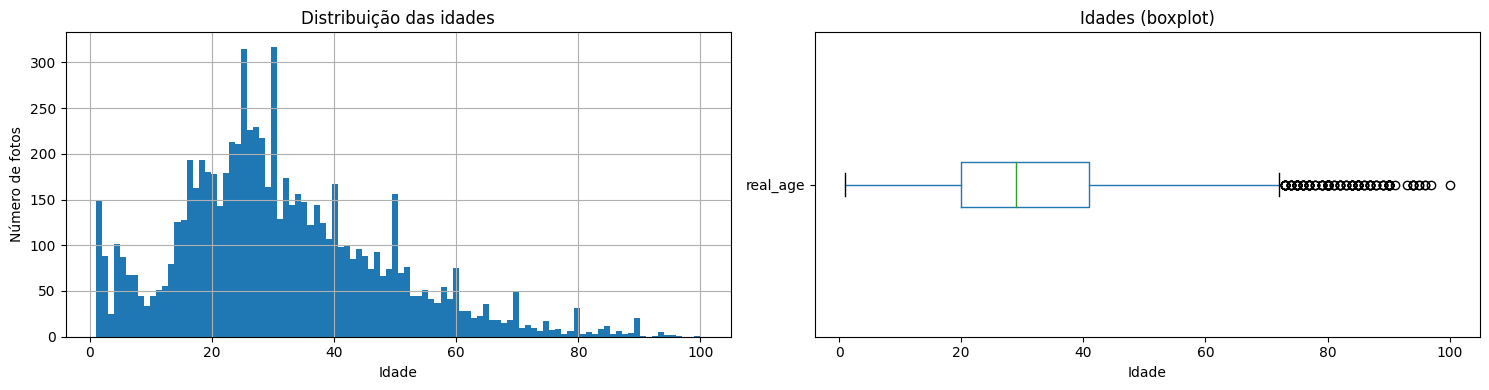

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))

labels['real_age'].hist(bins=100, ax=axs[0])
axs[0].set_title('Distribuição das idades')
axs[0].set_xlabel('Idade')
axs[0].set_ylabel('Número de fotos')

labels['real_age'].plot(kind='box', vert=False, ax=axs[1])
axs[1].set_title('Idades (boxplot)')
axs[1].set_xlabel('Idade')

plt.tight_layout()
plt.show()

Para deixar explícito quanto material o modelo tem de cada faixa etária, agrupo as
idades em intervalos de 10 anos e conto as fotos de cada um.

In [5]:
faixas = pd.cut(labels['real_age'], bins=range(0, 111, 10), right=False)

contagem = labels.groupby(faixas, observed=False)['real_age'].count()
proporcao = (contagem / contagem.sum() * 100).round(1)

resumo_faixas = pd.DataFrame({'fotos': contagem, 'percentual': proporcao})
display(resumo_faixas)

,fotos,percentual
real_age,,
"[0, 10)",663,8.7
"[10, 20)",1213,16.0
"[20, 30)",2075,27.3
"[30, 40)",1564,20.6
"[40, 50)",940,12.4
"[50, 60)",615,8.1
"[60, 70)",279,3.7
"[70, 80)",130,1.7
"[80, 90)",78,1.0


O histograma acima mostra picos isolados que se repetem de forma regular. Isso costuma
indicar rótulos arredondados, então confiro quais idades são as mais frequentes.

In [6]:
top_idades = labels['real_age'].value_counts().head(10)

display(top_idades)

30    317
25    315
27    229
26    226
28    217
23    213
24    211
18    193
16    193
19    180
Name: real_age, dtype: int64

### Encontrando 

Além dos números, é importante olhar as fotos. Imprimo 15 imagens cobrindo toda a
faixa etária, uma de cada década aproximadamente, para avaliar a qualidade e a
uniformidade do material.

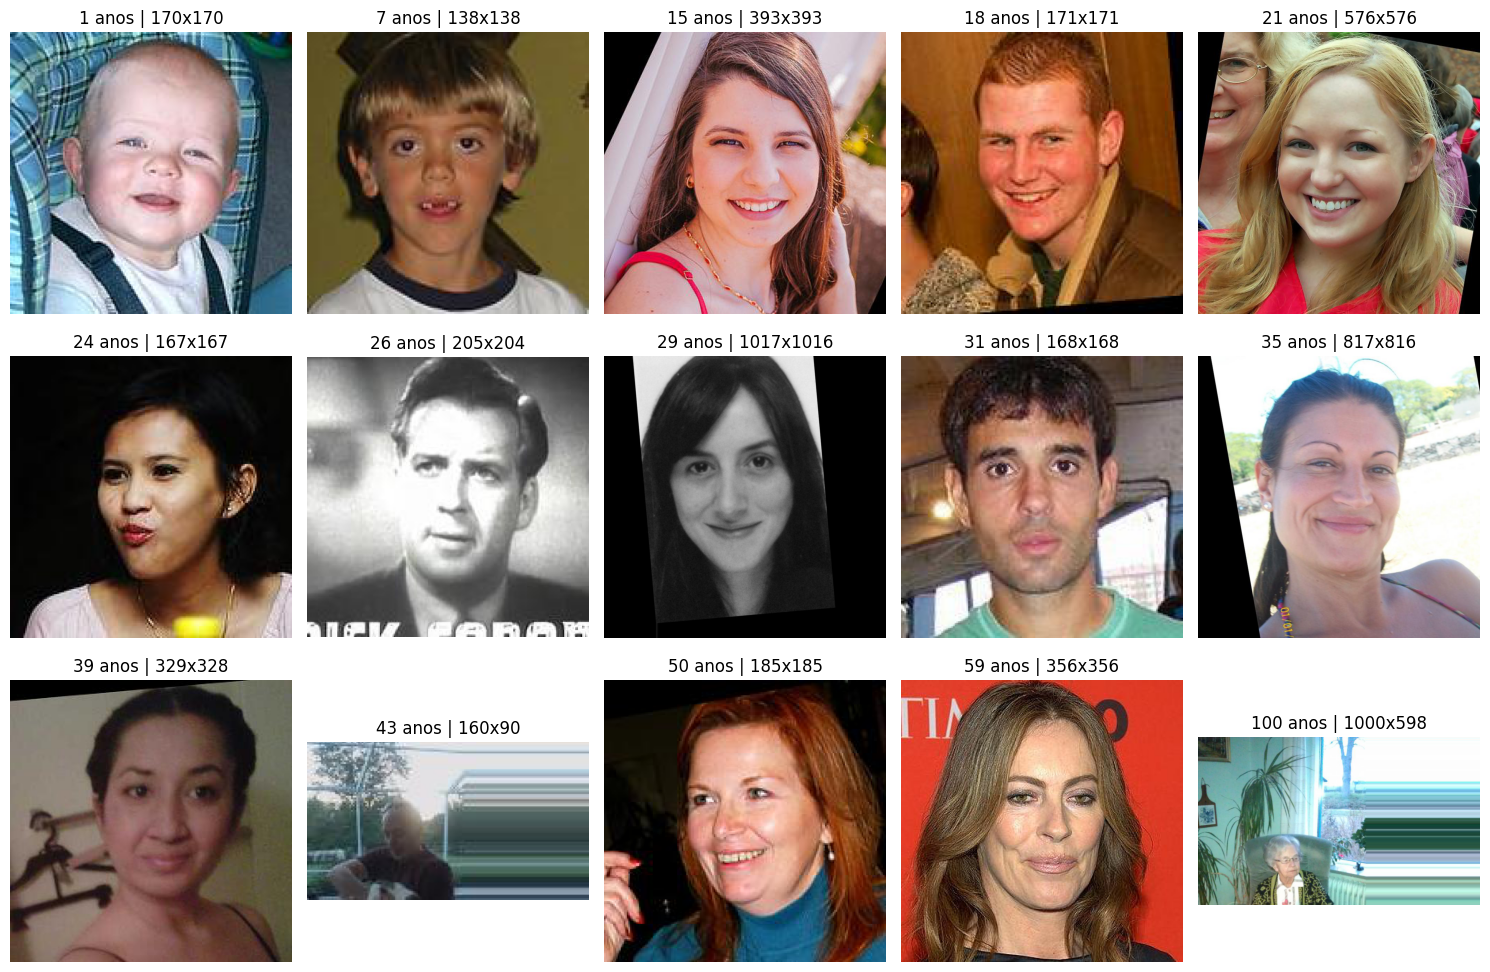

In [7]:
amostra = (labels
           .sort_values('real_age')
           .iloc[np.linspace(0, len(labels) - 1, 15, dtype=int)]
           .reset_index(drop=True))

fig, axs = plt.subplots(3, 5, figsize=(15, 10))

for i, ax in enumerate(axs.flat):
    imagem = Image.open(caminho + 'final_files/' + amostra.loc[i, 'file_name'])
    ax.imshow(imagem)
    ax.set_title(f"{amostra.loc[i, 'real_age']} anos | {imagem.size[0]}x{imagem.size[1]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

As fotos vêm em tamanhos diferentes, então também vale conferir as dimensões de uma
amostra maior antes de decidir o pré-processamento.

In [8]:
amostra_tamanhos = labels.sample(300, random_state=12345)

tamanhos = [Image.open(caminho + 'final_files/' + nome).size
            for nome in amostra_tamanhos['file_name']]

df_tamanhos = pd.DataFrame(tamanhos, columns=['largura', 'altura'])
display(df_tamanhos.describe().round(1))

,largura,altura
count,300.0,300.0
mean,454.8,456.6
std,323.3,343.7
min,57.0,57.0
25%,220.2,220.5
50%,383.5,384.5
75%,614.2,598.5
max,2364.0,3008.0


### Conclusões da análise exploratória

O conjunto tem 7591 fotos, sem valores ausentes e sem nomes de arquivo repetidos, então não
foi preciso nenhuma limpeza antes de montar os geradores.

**Distribuição das idades.** As idades vão de 1 a 100 anos, com média de 31,2 e mediana de
29. A distribuição é assimétrica à direita: metade das fotos está entre 20 e 41 anos, e as
faixas dos 20 aos 40 concentram sozinhas 47,9% do total. Crianças e adolescentes têm
representação razoável, com 8,7% na faixa de 0 a 9 anos e 16,0% na de 10 a 19.

A escassez está no outro extremo. De 60 anos em diante são 521 fotos (6,9%), de 70 em
diante são 242 (3,2%), e de 90 em diante restam 34. O modelo vai ver muitos exemplos de
adultos jovens e pouquíssimos de idosos, então tende a acertar bem no centro da
distribuição e errar mais no topo. Como o conjunto de teste segue a mesma distribuição, o
erro nas faixas raras fica diluído no EAM: o número final pode parecer bom mesmo com o
modelo indo mal com pessoas mais velhas. Também é esperado que as previsões sejam puxadas
para o centro, porque prever algo perto de 30 é o que minimiza o erro médio quando falta
informação.

Para o caso de uso da Boa Semente, essa concentração até ajuda. A idade que importa na
venda de álcool fica na região dos 18 anos, e as faixas de 10 a 19 e de 20 a 29 juntas
somam 43,3% das fotos, então é justamente onde o modelo terá mais material para aprender.

**Idades arredondadas.** O histograma mostra picos isolados que se repetem em intervalos
regulares, e a contagem das idades mais frequentes confirma a suspeita: parte dos rótulos
foi arredondada para múltiplos de 5 e 10. Isso significa que o próprio rótulo carrega erro,
já que uma pessoa registrada como "30" pode ter 28 ou 32. Nenhum modelo consegue ficar
abaixo do ruído do rótulo, então existe um piso de erro que não depende da arquitetura.

**Tamanho e formato das imagens.** As fotos não têm tamanho padrão. Na amostra de 300
arquivos, a largura vai de 57 a 2364 pixels e a altura chega a 3008, com mediana em torno
de 384. Redimensionar tudo para 224x224 é obrigatório, e isso significa ampliar as imagens
pequenas, que ficam borradas, e reduzir as grandes. Nem todas são quadradas: entre as 15
fotos impressas apareceram uma de 160x90 e outra de 1000x598, e nesses casos o
redimensionamento para um quadrado distorce as proporções do rosto.

**Qualidade e enquadramento.** A maior parte das fotos é um recorte fechado no rosto, mas
não todas. A de 43 anos e a de 100 anos mostram a pessoa distante, ocupando uma fração
pequena da imagem. A de 21 anos tem duas pessoas no enquadramento. Também há imagens em
preto e branco, como as de 26 e 29 anos, e variação grande de iluminação, ângulo e
expressão.

Esses casos funcionam como ruído: o modelo recebe um rótulo de idade para uma imagem onde o
rosto quase não aparece. Não dá para removê-los sem inspecionar as 7591 fotos uma a uma,
então a saída é aceitar que somam ao piso de erro já imposto pelos rótulos arredondados.

**Decisões que essas observações justificam.** Como o enquadramento já é irregular, evitei
augmentação que mexa em posição ou escala, como rotação e zoom, porque isso agravaria um
problema que já existe. Mantive apenas o espelhamento horizontal, que é seguro para rostos
e não altera a idade. A augmentação fica só no gerador de treinamento; o de teste recebe
apenas o reescalonamento, para que a avaliação use as imagens originais.

## Modelagem

Defina as funções necessárias para treinar seu modelo na plataforma GPU e construa um único script contendo todas elas junto com a seção de inicialização.
Para facilitar essa tarefa, você pode defini-las neste notebook e executar um código pronto na próxima seção para compor o script automaticamente.
As definições abaixo também serão verificadas pelos revisores do projeto, para que possam entender como você construiu o modelo.

In [9]:
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam

Como todas as fotos estão em uma única pasta, a separação entre treinamento e teste é
feita pelo próprio gerador, com `validation_split=0.25`. As duas funções usam o mesmo
valor de divisão e a mesma semente, o que garante que nenhuma foto apareça nos dois
conjuntos.

In [10]:
def load_train(path):
    
    """
    Carrega a parte de treinamento do conjunto de dados a partir do caminho
    """
    
    labels = pd.read_csv(path + 'labels.csv')

    train_datagen = ImageDataGenerator(
        rescale=1 / 255.,
        validation_split=0.25,
        horizontal_flip=True)

    train_gen_flow = train_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='training',
        seed=12345)

    return train_gen_flow

In [11]:
def load_test(path):
    
    """
    Carrega a parte de validação/teste do conjunto de dados a partir do caminho
    """
    
    labels = pd.read_csv(path + 'labels.csv')

    test_datagen = ImageDataGenerator(
        rescale=1 / 255.,
        validation_split=0.25)

    test_gen_flow = test_datagen.flow_from_dataframe(
        dataframe=labels,
        directory=path + 'final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='validation',
        seed=12345)

    return test_gen_flow

O modelo usa a ResNet50 pré-treinada na ImageNet como extratora de características. A
transferência de aprendizado faz sentido aqui porque 7591 fotos são poucas para treinar uma
rede profunda do zero, enquanto os pesos da ImageNet já codificam bordas, texturas e formas
que servem para qualquer imagem natural.

O `include_top=False` remove as camadas finais de classificação da ResNet, que foram
treinadas para separar as 1000 categorias da ImageNet e não têm utilidade para regressão de
idade. No lugar delas entra o `GlobalAveragePooling2D`, que reduz cada mapa de
características a um único número tirando a média espacial. Ele foi escolhido em vez do
`Flatten` porque produz um vetor muito menor, o que corta drasticamente o número de
parâmetros da camada seguinte e reduz o risco de sobreajuste.

A saída é um único neurônio, já que a previsão é um número e não uma classe. A ativação
`relu` garante que a idade prevista nunca seja negativa.

A função de perda é o EQM e a métrica de acompanhamento é o EAM. O enunciado explica o
motivo: redes com EQM convergem mais rápido, porque elevar o erro ao quadrado produz
gradientes maiores, mas a avaliação do projeto usa o EAM. A taxa de aprendizado de 0,0005 é
baixa de propósito: como os pesos da ImageNet já são bons, passos grandes destruiriam o que
a rede sabe antes de ela se ajustar à nova tarefa.

In [12]:
def create_model(input_shape):
    
    """
    Define o modelo
    """
    
    backbone = ResNet50(weights='imagenet',
                        input_shape=input_shape,
                        include_top=False)

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))

    optimizer = Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    return model

In [13]:
def train_model(model, train_data, test_data, batch_size=None, epochs=20,
                steps_per_epoch=None, validation_steps=None):

    """
    Treina o modelo de acordo com os parâmetros
    """
    
    if steps_per_epoch is None:
        steps_per_epoch = len(train_data)

    if validation_steps is None:
        validation_steps = len(test_data)

    model.fit(train_data,
              validation_data=test_data,
              batch_size=batch_size,
              epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2)

    return model

Os parâmetros de treinamento seguem a mesma lógica. O lote de 32 imagens aproveita bem a
memória da GPU sem deixar as atualizações de peso instáveis, e é o dobro do exemplo da
lição, o que reduz o tempo de cada época. As 20 épocas vêm do valor padrão do template:
com uma taxa de aprendizado baixa, a rede precisa de várias passagens para convergir.

O `steps_per_epoch` e o `validation_steps` recebem o tamanho de cada gerador, garantindo
que toda época percorra o conjunto inteiro uma vez. O `verbose=2` imprime uma linha por
época em vez da barra de progresso, o que deixa a saída da plataforma GPU legível para
colar no notebook.

### Preparar o Script para execução na plataforma GPU

Dado que você definiu as funções necessárias, você pode compor um script para a plataforma GPU, baixá-lo através do menu "Arquivo|Abrir..." e carregá-lo posteriormente para execução na plataforma GPU.

Nota: O script também deve incluir a seção de inicialização. Um exemplo disso é mostrado abaixo.

In [14]:
# preparar um script para ser executado na plataforma GPU

init_str = """
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
"""

run_str = """
path = '/datasets/faces/'

train_data = load_train(path)
test_data = load_test(path)
model = create_model(input_shape=(224, 224, 3))
model = train_model(model, train_data, test_data)
"""

import inspect

with open('run_model_on_gpu.py', 'w') as f:
    
    f.write(init_str)
    f.write('\n\n')
        
    for fn_name in [load_train, load_test, create_model, train_model]:
        
        src = inspect.getsource(fn_name)
        f.write(src)
        f.write('\n\n')

    f.write(run_str)

### Saída

Coloque a saída da plataforma GPU como uma célula Markdown aqui.

```
Found 5694 validated image filenames.
Found 1897 validated image filenames.
Downloading data from https://storage.googleapis.com/tensorflow/keras-applications/resnet/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
178/178 - 159s - 895ms/step - loss: 201.1648 - mae: 10.5291 - val_loss: 402.4263 - val_mae: 15.0775
Epoch 2/20
178/178 - 59s - 331ms/step - loss: 111.7603 - mae: 8.0272 - val_loss: 447.0604 - val_mae: 16.0180
Epoch 3/20
178/178 - 60s - 337ms/step - loss: 92.0564 - mae: 7.2850 - val_loss: 341.8018 - val_mae: 13.7629
Epoch 4/20
178/178 - 61s - 344ms/step - loss: 75.2210 - mae: 6.5709 - val_loss: 218.8552 - val_mae: 10.9861
Epoch 5/20
178/178 - 62s - 346ms/step - loss: 64.6462 - mae: 6.1075 - val_loss: 208.3189 - val_mae: 11.5849
Epoch 6/20
178/178 - 83s - 464ms/step - loss: 56.1104 - mae: 5.7037 - val_loss: 99.6221 - val_mae: 7.4337
Epoch 7/20
178/178 - 66s - 373ms/step - loss: 42.8773 - mae: 5.0331 - val_loss: 117.6508 - val_mae: 8.1409
Epoch 8/20
178/178 - 63s - 354ms/step - loss: 38.2981 - mae: 4.7640 - val_loss: 79.3634 - val_mae: 6.6822
Epoch 9/20
178/178 - 63s - 354ms/step - loss: 34.2040 - mae: 4.4449 - val_loss: 99.3811 - val_mae: 7.6079
Epoch 10/20
178/178 - 63s - 354ms/step - loss: 29.6518 - mae: 4.1902 - val_loss: 119.9825 - val_mae: 8.5267
Epoch 11/20
178/178 - 62s - 351ms/step - loss: 24.0534 - mae: 3.7535 - val_loss: 80.3437 - val_mae: 6.8079
Epoch 12/20
178/178 - 63s - 355ms/step - loss: 22.3079 - mae: 3.6666 - val_loss: 76.7785 - val_mae: 6.5799
Epoch 13/20
178/178 - 62s - 348ms/step - loss: 22.0074 - mae: 3.5675 - val_loss: 79.6311 - val_mae: 6.6948
Epoch 14/20
178/178 - 63s - 351ms/step - loss: 19.2727 - mae: 3.3921 - val_loss: 79.0881 - val_mae: 6.5972
Epoch 15/20
178/178 - 62s - 349ms/step - loss: 15.9352 - mae: 3.0297 - val_loss: 73.9592 - val_mae: 6.3440
Epoch 16/20
178/178 - 62s - 348ms/step - loss: 16.4689 - mae: 3.0833 - val_loss: 80.5396 - val_mae: 6.5987
Epoch 17/20
178/178 - 63s - 353ms/step - loss: 15.5101 - mae: 3.0337 - val_loss: 81.3308 - val_mae: 6.8521
Epoch 18/20
178/178 - 62s - 349ms/step - loss: 15.2891 - mae: 3.0187 - val_loss: 77.3702 - val_mae: 6.5162
Epoch 19/20
178/178 - 62s - 350ms/step - loss: 14.0977 - mae: 2.8908 - val_loss: 69.2280 - val_mae: 6.2081
Epoch 20/20
178/178 - 62s - 350ms/step - loss: 14.4413 - mae: 2.8996 - val_loss: 96.5832 - val_mae: 7.3113
```

O treinamento foi executado em uma GPU Tesla T4, via google colab. A primeira época levou 159 segundos e as
demais ficaram em torno de 62 segundos, já que as imagens passaram a ser lidas do cache de
disco. O total foi de aproximadamente 22 minutos.

## Conclusões

### Resultado alcançado

O modelo terminou o treinamento com **EAM de 7,31 anos no conjunto de teste**, abaixo do
limite de 8 exigido pelo projeto. Como referência, o artigo original deste conjunto de dados
relata o melhor valor conhecido em 5,4 anos.

Vale colocar esse número em perspectiva. Um modelo que ignorasse a foto e respondesse sempre
a mediana das idades erraria em torno de 13,7 anos. O modelo treinado reduz esse erro em
aproximadamente 47%, então ele está de fato extraindo informação das imagens e não apenas
aprendendo a distribuição do conjunto.

### Comportamento ao longo das épocas

A evolução se divide em três fases bem distintas.

Nas cinco primeiras épocas o erro de validação foi alto e instável, variando entre 11,0 e
16,0. Na época 1 o EAM de validação chegou a 15,1, pior que simplesmente prever a mediana.
Isso é esperado: a camada de saída começa com pesos aleatórios e leva algumas passagens até
produzir valores na escala certa.

Entre as épocas 6 e 10 o erro caiu para a faixa de 6,7 a 8,5, ainda oscilando bastante.

Da época 11 em diante o modelo estabilizou. O EAM de validação ficou entre 6,21 e 6,85 em
oito das nove épocas seguintes, com média de 6,65 nas últimas dez. O melhor resultado foi na
época 19, com 6,21.

A época 20, que é a que define o modelo final, registrou 7,31. Esse valor é o pior da reta
final e destoa das épocas vizinhas, então parte dele é flutuação do próprio processo de
otimização e não uma piora real do modelo. O ponto prático é que a partir da época 12 o
ganho se tornou marginal: parar por volta da época 15 daria um resultado equivalente com 25%
menos tempo de treinamento.

### Sobreajuste

O modelo está claramente sobreajustado. Na última época o EAM de treinamento foi 2,90 contra
7,31 na validação, uma diferença de 2,5 vezes. O erro de treinamento continuou caindo até o
fim, enquanto o de validação parou de melhorar por volta da época 12.

Isso é esperado e aceitável neste caso, e o próprio enunciado do projeto antecipa a
situação. A ResNet50 tem mais de 23 milhões de parâmetros para apenas 5694 imagens de
treinamento, então ela tem capacidade de sobra para memorizar o conjunto. O que importa é
que a qualidade na validação se manteve estável em vez de degradar, o que indica que a
memorização não veio às custas da generalização.

Se o objetivo fosse espremer mais desempenho, os caminhos naturais seriam parada antecipada
monitorando o EAM de validação, uma camada de `Dropout` antes da saída, ou congelar as
primeiras camadas da ResNet50 para reduzir o número de parâmetros treináveis.

### Relação com as características do conjunto

O erro obtido é coerente com o que a análise exploratória permitia esperar, e há três
limitações que estabelecem um piso que nenhuma escolha de arquitetura resolveria.

Os rótulos carregam erro próprio, já que parte das idades foi arredondada para múltiplos de
5 e 10. Um modelo não consegue ser mais preciso que a informação que recebe.

O material é desigual entre as faixas etárias. Acima de 60 anos há apenas 6,9% das fotos, e
acima de 90 restam 34 imagens. O erro nessas faixas é necessariamente maior, mas fica
diluído no EAM porque o conjunto de teste segue a mesma distribuição do treinamento.

Parte das imagens não é adequada para a tarefa. Entre as 15 fotos inspecionadas apareceram
casos com a pessoa distante ocupando pouco espaço do enquadramento, uma foto com duas
pessoas e imagens em preto e branco. Esses casos entram no treinamento como ruído.

### Aplicação ao caso da Boa Semente

O modelo atinge a meta técnica do projeto, mas um erro médio de 7,3 anos é grande demais
para decidir sozinho sobre a venda de álcool.

O problema fica evidente ao aplicar a margem ao limite legal. Uma pessoa de 25 anos pode ser
estimada em 18, e uma de 16 pode ser estimada em 23. Como o erro é uma média, casos
individuais ficam ainda mais distantes. Autorizar ou bloquear uma venda com base apenas
nessa previsão levaria tanto a vender para menores quanto a constranger clientes adultos.

O uso realista é como filtro, não como decisor. O sistema pode liberar automaticamente os
casos em que a idade prevista é folgadamente alta, por exemplo acima de 35 anos, onde mesmo
um erro de 7 anos mantém a pessoa acima do limite legal. Todos os casos abaixo desse patamar
seriam encaminhados para conferência humana de documento. Isso reduz o trabalho do operador
sem transferir a decisão legal para o modelo.

Um ponto favorável apareceu na análise exploratória: as faixas de 10 a 19 e de 20 a 29 anos
concentram 43,3% das fotos, ou seja, a região próxima do limite legal é justamente a mais
bem representada no treinamento. Isso sugere que o desempenho na faixa que importa para o
negócio é melhor que a média geral. Confirmar isso exigiria medir o EAM por faixa etária em
vez de olhar apenas o número agregado, e seria o próximo passo natural antes de qualquer
decisão sobre uso real.

# Checklist

- [x]  O notebook foi aberto
- [x]  O código está livre de erros 
- [x]  As células com código foram organizadas por ordem de execução
- [x]  A análise exploratória dos dados foi realizada 
- [x]  Os resultados da análise exploratória dos dados são apresentados no caderno final 
- [x]  O valor EAM do modelo não é superior a 8
- [x]  O código de treinamento do modelo foi copiado para o notebook final 
- [x]  A saída do treinamento do modelo foi copiada para o notebook final 
- [x]  As conclusões foram fornecidas com base nos resultados do treinamento do modelo